In [ ]:
import glob
import re
import pandas as pd

pattern = "../docking_results_3oxz/lig_*_out.pdbqt"
files = glob.glob(pattern)

results = []
for file in files:
    with open(file, 'r') as f:
        for line in f:
            if line.startswith("REMARK VINA RESULT:"):
                parts = line.split()
                match = re.search(r'REMARK VINA RESULT:\s+([-\d.]+)', line)
                if match:
                    value = float(match.group(1))
                    results.append({'file': file, 'value': value})
                break

df = pd.DataFrame(results)
print(df)

                                        file  value
0   ../docking_results_3oxz\lig_10_out.pdbqt -5.927
1   ../docking_results_3oxz\lig_11_out.pdbqt -5.999
2   ../docking_results_3oxz\lig_12_out.pdbqt -5.003
3   ../docking_results_3oxz\lig_13_out.pdbqt -6.079
4   ../docking_results_3oxz\lig_14_out.pdbqt -5.792
5   ../docking_results_3oxz\lig_15_out.pdbqt -5.252
6   ../docking_results_3oxz\lig_16_out.pdbqt -4.956
7   ../docking_results_3oxz\lig_17_out.pdbqt -4.568
8   ../docking_results_3oxz\lig_19_out.pdbqt -4.337
9    ../docking_results_3oxz\lig_1_out.pdbqt -5.620
10  ../docking_results_3oxz\lig_20_out.pdbqt -5.177
11  ../docking_results_3oxz\lig_21_out.pdbqt -5.722
12  ../docking_results_3oxz\lig_22_out.pdbqt -5.205
13  ../docking_results_3oxz\lig_23_out.pdbqt -5.156
14  ../docking_results_3oxz\lig_24_out.pdbqt -5.987
15  ../docking_results_3oxz\lig_25_out.pdbqt -4.952
16  ../docking_results_3oxz\lig_26_out.pdbqt -5.006
17  ../docking_results_3oxz\lig_27_out.pdbqt -5.876
18  ../docki

In [8]:
print('min:', df['value'].min())
print('max:', df['value'].max())
print('mean:', df['value'].mean())

min: -6.362
max: -4.103
mean: -5.383703703703704


In [15]:
pattern_dataset = "../docking_results_3oxz_dataset/dataset-*_out.pdbqt"
files_dataset = glob.glob(pattern_dataset)

results = []
for file in files_dataset:
    with open(file, 'r') as f:
        for line in f:
            if line.startswith("REMARK VINA RESULT:"):
                parts = line.split()
                match = re.search(r'REMARK VINA RESULT:\s+([-\d.]+)', line)
                if match:
                    value = float(match.group(1))
                    results.append({'file': file, 'value': value})
                break

df_result = pd.DataFrame(results)
print(df_result)

                                                  file  value
0    ../docking_results_3oxz_dataset\dataset-100_ou... -5.228
1    ../docking_results_3oxz_dataset\dataset-101_ou... -5.585
2    ../docking_results_3oxz_dataset\dataset-102_ou... -5.709
3    ../docking_results_3oxz_dataset\dataset-103_ou... -4.883
4    ../docking_results_3oxz_dataset\dataset-104_ou... -5.625
..                                                 ...    ...
194  ../docking_results_3oxz_dataset\dataset-96_out... -5.070
195  ../docking_results_3oxz_dataset\dataset-97_out... -5.517
196  ../docking_results_3oxz_dataset\dataset-98_out... -6.301
197  ../docking_results_3oxz_dataset\dataset-99_out... -5.469
198  ../docking_results_3oxz_dataset\dataset-9_out.... -5.659

[199 rows x 2 columns]


In [16]:
print('min:', df_result['value'].min())
print('max:', df_result['value'].max())
print('mean:', df_result['value'].mean())

min: -7.145
max: -3.786
mean: -5.494130653266334


In [17]:
print('Результаты:')
print('min:', df['value'].min())
print('max:', df['value'].max())
print('mean:', df['value'].mean())
print('Датасет')
print('min:', df_result['value'].min())
print('max:', df_result['value'].max())
print('mean:', df_result['value'].mean())

Результаты:
min: -6.362
max: -4.103
mean: -5.383703703703704
Датасет
min: -7.145
max: -3.786
mean: -5.494130653266334


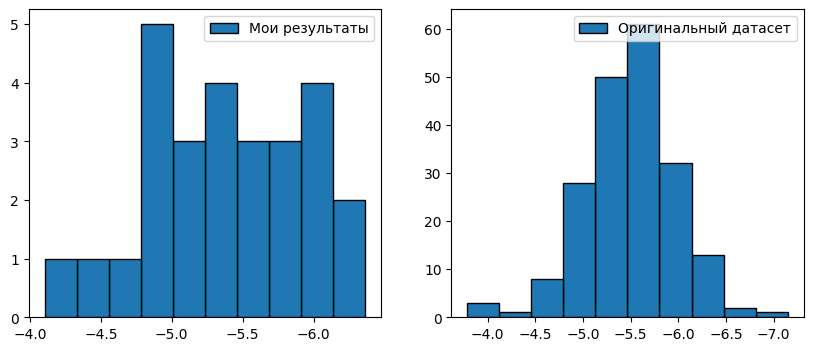

In [33]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
ax1.hist(df['value'], bins=10, edgecolor='black', label='Мои результаты')
ax2.hist(df_result['value'], bins=10, edgecolor='black',  label='Оригинальный датасет')
ax1.invert_xaxis()
ax2.invert_xaxis()
ax1.legend()
ax2.legend()
plt.show()